# Closed-loop control

**Scientific question.** When the calibrated sensor, deformable mirror, and a
leaky-integrator controller are connected around a frozen-flow atmosphere, does
the shared closed-loop engine reduce the residual wavefront error below the
uncorrected (open-loop) level and settle to a steady state within a few frames?

Every component here — atmosphere, sensor, mirror, reconstructor, controller,
and the loop engine `shwfs_ao.control.run_closed_loop` — is an installed API.
The notebook defines no loop of its own.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
GAIN = 0.5
N_STEPS = 12

## Configuration

In [2]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(48, 48),
    n_lenslets_across=4,
    min_fill_fraction=0.3,
)
pupil = geometry.pupil_geometry
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=2e4),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=5,
        coupling_width_pitch=0.35,
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=25e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
atmosphere = FrozenFlowAtmosphere(
    FrozenFlowAtmosphereConfig(
        grid_size=geometry.pupil_shape[0],
        delta_m=pupil.pixel_spacing_xy_m[0],
        pupil_diameter_m=TELESCOPE_DIAMETER_M,
        r0_m=0.4,
        outer_scale_m=25.0,
        wind_m_per_s=(6.0, 0.0),
        root_seed=SEED,
    ),
    pupil_mask=geometry.pupil_mask,
)

## Simulation call

In [3]:
history = run_closed_loop(
    LoopConfig(
        n_steps=N_STEPS,
        gain=GAIN,
        leak=0.0,
        latency_frames=0,
        frame_rate_hz=500.0,
        root_seed=SEED,
    ),
    random_streams=NamedRandomStreams(SEED),
    atmosphere=atmosphere,
    wfs=sensor,
    dm=mirror,
    interaction_matrix=interaction,
    reconstructor=LeastSquaresReconstructor(
        interaction, min_valid_fraction=0.5, min_rank=1
    ),
    command_projector=IdentityCommandProjector(mirror.actuator_ids),
    controller=LeakyIntegratorController(
        mirror.actuator_ids, gain=GAIN, leak=0.0, latency_frames=0
    ),
    include_noise=False,
    realization_index=0,
)
open_loop = np.asarray(history.open_loop_opd_rms_m, dtype=float)
closed_loop = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)

## Diagnostic table

In [4]:
settled = slice(N_STEPS // 2, None)
table = pd.DataFrame(
    [
        ("Open-loop RMS (mean)", float(np.mean(open_loop)) * 1e9, "nm"),
        ("Closed-loop RMS (final half)", float(np.mean(closed_loop[settled])) * 1e9, "nm"),
        (
            "Residual fraction",
            float(np.mean(closed_loop[settled]) / np.mean(open_loop)),
            "-",
        ),
        ("Loop backend", history.metadata["backend_names"]["dm"], ""),
    ],
    columns=["quantity", "value", "units"],
)
table

,quantity,value,units
0,Open-loop RMS (mean),187.032111,nm
1,Closed-loop RMS (final half),141.731465,nm
2,Residual fraction,0.757792,-
3,Loop backend,native,


## Plot

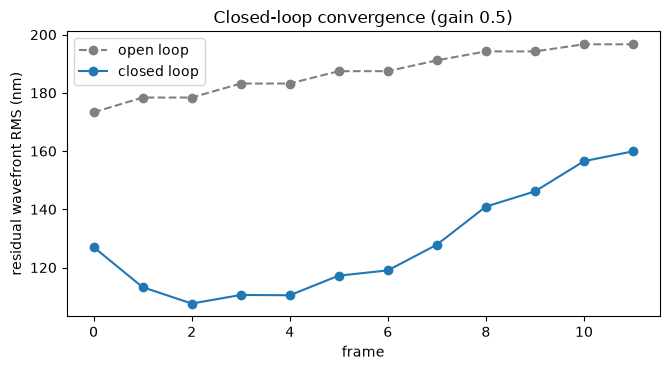

In [5]:
frames = np.arange(N_STEPS)
figure, axis = plt.subplots(figsize=(6.8, 3.8))
axis.plot(frames, open_loop * 1e9, "o--", color="0.5", label="open loop")
axis.plot(frames, closed_loop * 1e9, "o-", color="C0", label="closed loop")
axis.set_xlabel("frame")
axis.set_ylabel("residual wavefront RMS (nm)")
axis.set_title(f"Closed-loop convergence (gain {GAIN})")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

Within a few frames the closed-loop residual drops below the open-loop level and
settles to a steady state, demonstrating that the calibrated interaction matrix
and the leaky integrator form a stable, converging correction. The residual does
not fall to zero: it settles at a fitting-error floor set by the coarse `5×5`
actuator grid, which cannot represent the highest spatial frequencies in the
screen. Raising the actuator count lowers that floor — the study notebooks reuse
this same `run_closed_loop` engine at higher order to show exactly that.

## Limitations

- Gentle seeing (`r0 = 0.4 m`) and a small pupil keep the notebook fast; harder
  turbulence needs more actuators and higher order.
- Measurement noise and loop latency are disabled here; both are scanned in
  `studies/noise_latency_gain.ipynb`.
- A single atmospheric realization is replayed; performance figures should be
  averaged over seeds.